In [ ]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
import numpy as np
from collections import OrderedDict
from statsmodels.tsa.statespace.sarimax import SARIMAX
from SARIMAX import DailySARIMAX, SarimaxConfig
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
from datetime import timedelta
import warnings

In [2]:
# Set these env vars or hardcode them
PGHOST = os.getenv("PGHOST", "localhost")
PGPORT = os.getenv("PGPORT", "5432")
PGDB   = os.getenv("PGDATABASE", "postgres")
PGUSER = os.getenv("PGUSER", "postgres")
PGPASS = os.getenv("PGPASSWORD", "Cantunez-02")


In [3]:
engine = create_engine(f"postgresql+psycopg2://{PGUSER}:{PGPASS}@{PGHOST}:{PGPORT}/{PGDB}")

In [4]:
def load_table(schema: str, table: str) -> pd.DataFrame:
    q = text(f'SELECT * FROM {schema}.{table}')
    with engine.begin() as conn:
        return pd.read_sql(q, conn)

In [5]:
df_consumption = load_table("GateGroup", "Consumption_Estimation")
df_expiration  = load_table("GateGroup", "ExpirationDate_Mgmt")
df_productivity  = load_table("GateGroup", "drawers_import")
df_flights  = load_table("GateGroup", "DailyFlights")

In [6]:
df_consumption = df_consumption.drop(columns=["crew_feedback"])
df_consumption.head()

,flight_id,origin,date,flight_type,service_type,passenger_count,product_id,product_name,standard_specification_qty,quantity_returned,quantity_consumed,unit_cost
0,AM109,DOH,2025-09-26,medium-haul,Retail,272,BRD001,Bread Roll Pack,62,7,55,0.35
1,AM109,DOH,2025-09-26,medium-haul,Retail,272,CRK075,Butter Cookies 75g,74,14,60,0.75
2,AM109,DOH,2025-09-26,medium-haul,Retail,272,DRK023,Sparkling Water 330ml,125,30,95,0.45
3,AM109,DOH,2025-09-26,medium-haul,Retail,272,DRK024,Still Water 500ml,110,19,91,0.50
4,LX110,DOH,2025-09-26,medium-haul,Pick & Pack,272,BRD001,Bread Roll Pack,177,58,119,0.35


In [7]:
num_cols = ["passenger_count","standard_specification_qty","quantity_returned",
            "quantity_consumed","unit_cost"]
for c in num_cols:
    df_consumption[c] = pd.to_numeric(df_consumption[c], errors="coerce")

# 4) Crea diccionarios para cada columna no entera restante
cat_cols = ["flight_id","origin","flight_type","service_type",
            "product_id","product_name"]

encoders = {}
decoders = {}

for col in cat_cols:
    uniques = OrderedDict()
    for v in df_consumption[col].tolist():
        if v not in uniques:
            uniques[v] = len(uniques)
    encoders[col] = dict(uniques)
    decoders[col] = {i:k for k,i in encoders[col].items()}
    df_consumption[col] = df_consumption[col].map(encoders[col]).astype("Int64")

In [8]:
df_consumption.head()

,flight_id,origin,date,flight_type,service_type,passenger_count,product_id,product_name,standard_specification_qty,quantity_returned,quantity_consumed,unit_cost
0,0,0,2025-09-26,0,0,272,0,0,62,7,55,0.35
1,0,0,2025-09-26,0,0,272,1,1,74,14,60,0.75
2,0,0,2025-09-26,0,0,272,2,2,125,30,95,0.45
3,0,0,2025-09-26,0,0,272,3,3,110,19,91,0.50
4,1,0,2025-09-26,0,1,272,0,0,177,58,119,0.35


cantidad de vuelos, issue de data collection en cathering, issue de como conectar fecha de caducidad con lo de retail (lo que se vende)

In [9]:
df_flights.head()

,day,day_id,flights_p2,flights_p1,%_cap_p1
0,2023-01-02,20230102,19,352,0.95
1,2023-01-03,20230103,23,356,0.93
2,2023-01-04,20230104,20,358,0.89
3,2023-01-05,20230105,21,365,0.89
4,2023-01-06,20230106,23,367,0.89


In [10]:
df = df_flights.copy()

In [11]:
dfA = df.drop(columns=["day_id", "flights_p2", "%_cap_p1"])
dfB = df.drop(columns=["day_id", "flights_p1", "%_cap_p1"])

In [12]:
df1 = dfB.copy()

In [13]:
df1.tail()

,day,flights_p2
968,2025-08-27,19
969,2025-08-28,17
970,2025-08-29,17
971,2025-08-30,15
972,2025-08-31,19


In [14]:
df1["flights_p2"] = df1["flights_p2"].replace(0, df1["flights_p2"].mean())

In [15]:
df_plot = df1.copy()
df_plot['day'] = pd.to_datetime(df_plot['day'])
df_plot = df_plot.set_index('day').sort_index()
ts = df_plot['flights_p2']

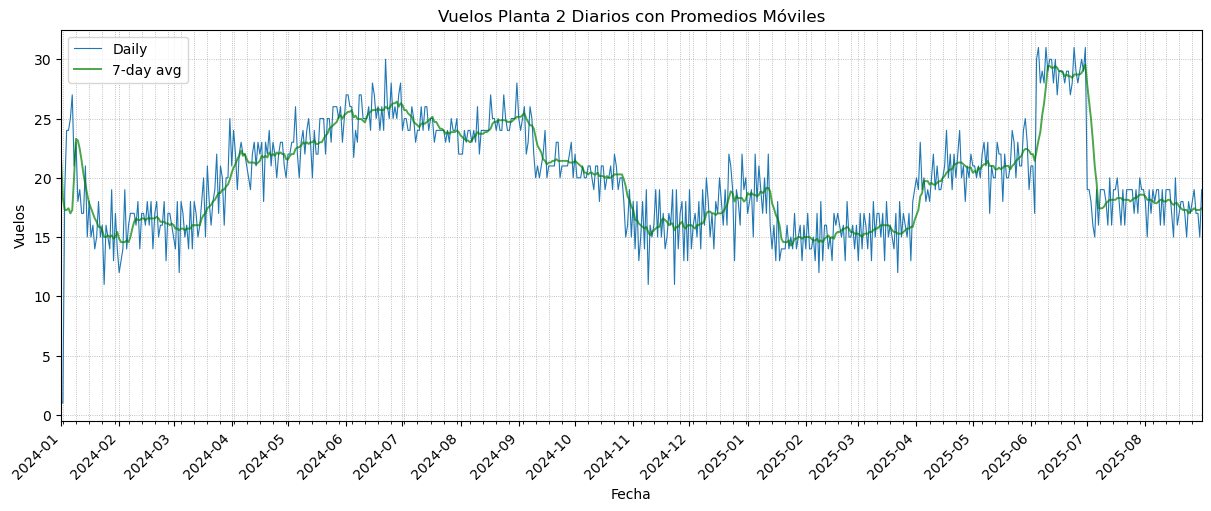

In [16]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

ts.plot(ax=ax, lw=0.8, label='Daily')
ts.rolling(7, min_periods=1).mean().plot(ax=ax, lw=1.4, alpha=0.7, color='green', label='7-day avg')

# Axes formatting for daily data since 2023
ax.set_xlim(pd.Timestamp('2024-01-01'), ts.index.max())
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1, interval=1))  # every 2 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_title('Vuelos Planta 2 Diarios con Promedios Móviles')
ax.set_xlabel('Fecha')
ax.set_ylabel('Vuelos')
ax.grid(True, which='both', linestyle=':', linewidth=0.6)
ax.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

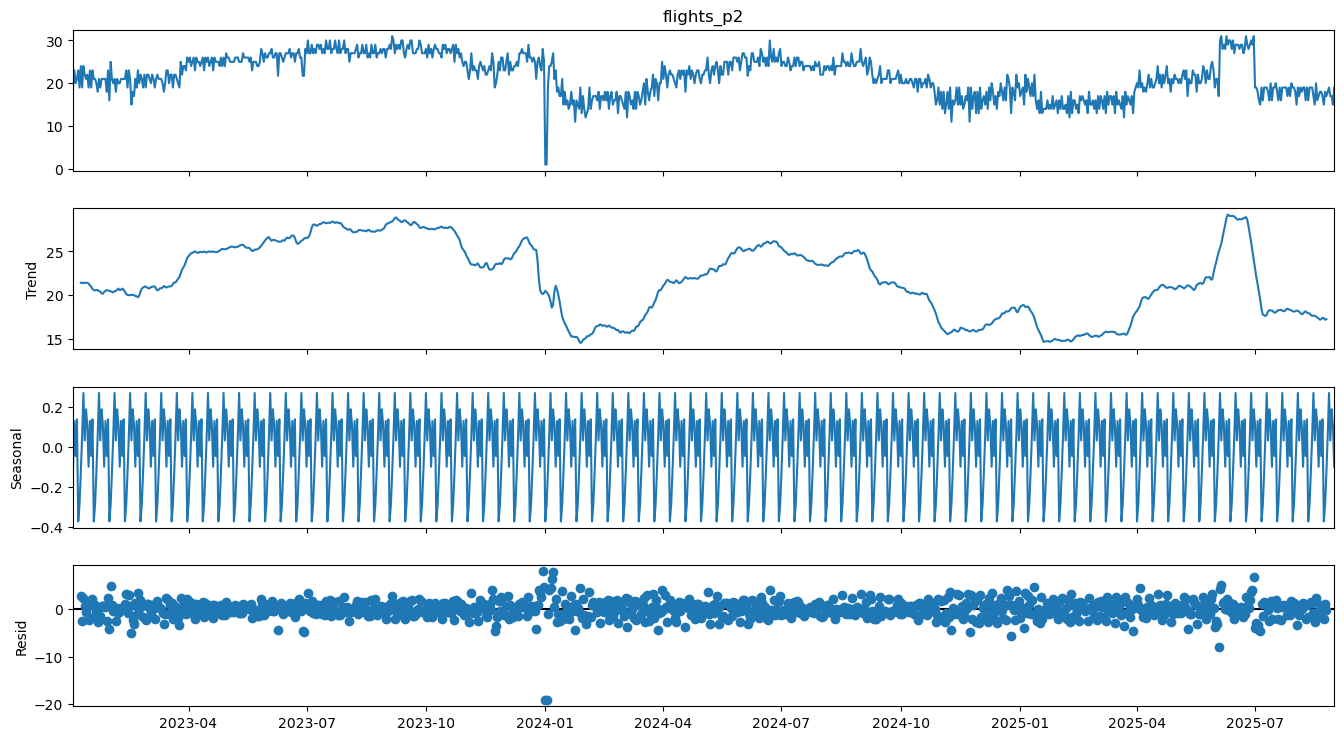

In [17]:
decomposition = seasonal_decompose(df_plot["flights_p2"], period=12)  
fig = plt.figure()  
fig = decomposition.plot()
fig.set_size_inches(15, 8)

In [18]:
data_trend = decomposition._trend
data_seasonal = decomposition._seasonal
data_ramdom = decomposition._resid

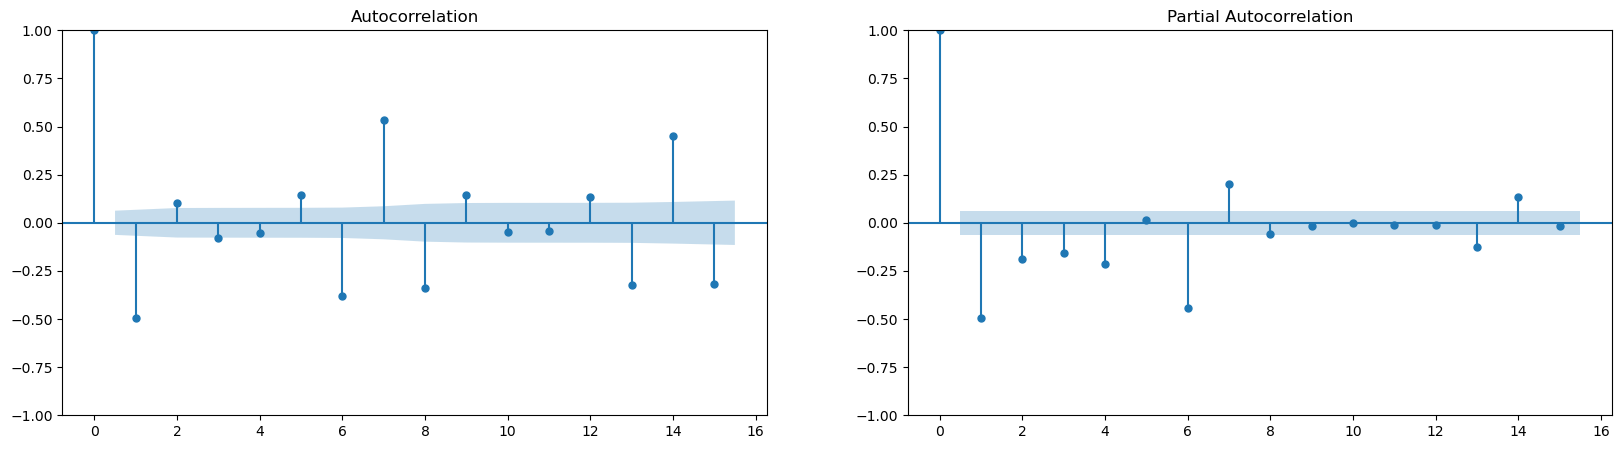

In [19]:
first_diff = (df_plot["flights_p2"] - df_plot["flights_p2"].shift(1))[1:]

def autocorrelation_plots(series_main_column, lags):
    fig, ax = plt.subplots(1,2, figsize=(20,5))
    plot_acf(series_main_column, lags=lags, ax=ax[0])
    plot_pacf(series_main_column, lags=lags, ax=ax[1])
    plt.show()

autocorrelation_plots(first_diff, 15)

p = 3, 
q = 4

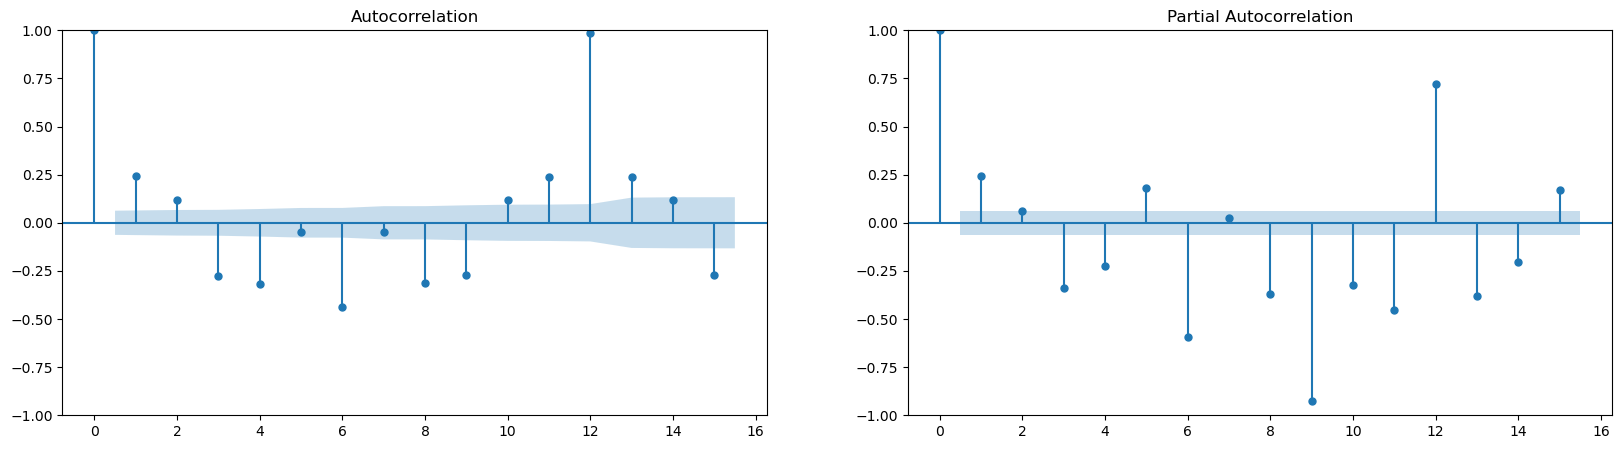

In [20]:
autocorrelation_plots(data_seasonal, 15)

P = 4, Q = 6

In [47]:
warnings.filterwarnings('ignore')
# Split the data into train and test
train_size = int(len(df_plot) * 0.80)
train, test = df_plot[0:train_size], df_plot[train_size:len(df_plot)]

# Fit the ARIMA model on the training dataset
model_train = SARIMAX(train['flights_p2'], order=(3,1,4), seasonal_order=(4,1,6,7))
model_train_fit = model_train.fit(disp=0)

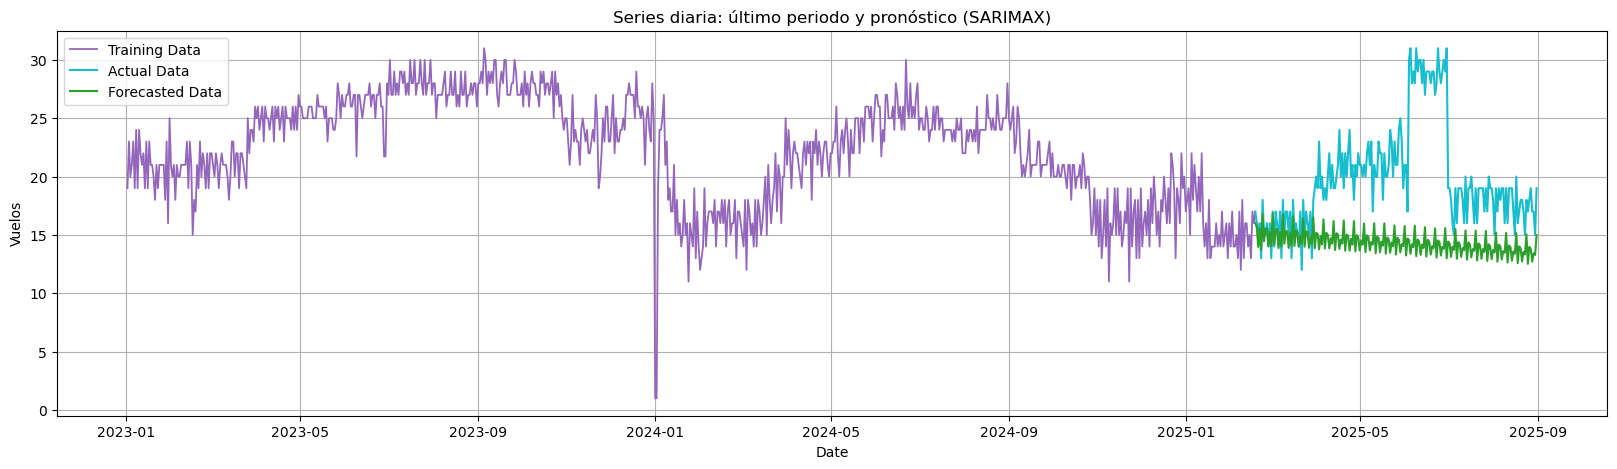

In [48]:
test_forecast = model_train_fit.forecast(len(test))
test_forecast_series = pd.Series(test_forecast, index=test.index)

font_name = "Serif"

# Create a plot to compare the forecast with the actual test data
plt.figure(figsize=(20,5))
plt.plot(df_plot[0:train_size+1]['flights_p2'],linewidth=1.3, c='tab:purple', label='Training Data')
plt.plot(test['flights_p2'], label='Actual Data', color='tab:cyan')
plt.plot(test_forecast_series, label='Forecasted Data', color='tab:green')
plt.title('Series diaria: último periodo y pronóstico (SARIMAX)')
plt.xlabel('Date')
plt.ylabel('Vuelos')
plt.legend()
plt.grid()
plt.show()

In [49]:
rolling_predictions = test['flights_p2'].copy()
for train_end in test['flights_p2'].index:
    train_data = df_plot[:train_end-timedelta(days=1)]
    model = SARIMAX(train_data, order=(0, 1, 0), seasonal_order = (3, 0, 1, 12))
    model_fit = model.fit(disp=0)
    pred = model_fit.forecast()
    rolling_predictions[train_end] = pred

#Plot config
font_name = "Serif"

# Create a plot to compare the forecast with the actual test data
plt.figure(figsize=(20,5))
plt.plot(df_plot[0:train_size+1]['flights_p2'],linewidth=1.3, c='tab:purple', label='Training Data')
plt.plot(test['flights_p2'], label='Actual Data', color='tab:cyan')
plt.plot(rolling_predictions, label='Forecasted Data', color='tab:green')
plt.title('Catfish Sales in 1000s of Pounds')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid()
plt.show()


NameError: name 'timedelta' is not defined

In [ ]:
m = DailySARIMAX(df1, date_col="day", value_col="flights_p2",
                 config=SarimaxConfig(order=(3,0,4), seasonal_order=(4,0,1,12)))
m.fit()
forecast_14d = m.forecast(steps=14)
fitted = m.predict_in_sample()
fitted.tail(20) 


KeyboardInterrupt: 

In [ ]:
metrics = m.validate(test_size=0.15, rolling_refit=True)
metrics

KeyboardInterrupt: 

In [ ]:
def plot_last_period_with_forecast(
    actual: pd.Series,
    forecast,
    period: pd.DateOffset = pd.DateOffset(months=1),
    title: str = "",
    ylabel: str = ""
) -> None:
    """
    actual: pd.Series with DatetimeIndex
    forecast: either pd.Series OR pd.DataFrame with columns ['mean','lower','upper']
    """
    # Ensure datetime index
    actual = pd.Series(actual).copy()
    actual.index = pd.to_datetime(actual.index)

    # Slice last window of actuals
    last_start = actual.index.max() - period
    y_last = actual[actual.index >= last_start]

    # Normalize forecast to DataFrame with mean/CI if available
    if isinstance(forecast, pd.Series):
        f_df = pd.DataFrame({"mean": forecast.astype(float)})
        f_df.index = pd.to_datetime(f_df.index)
    else:
        f_df = forecast.copy()
        f_df.index = pd.to_datetime(f_df.index)

    plt.figure(figsize=(10, 5))
    plt.plot(y_last.index, y_last.values, label="Actual (último periodo)")
    plt.plot(f_df.index, f_df["mean"].values, label=f"Pronóstico ({len(f_df)} pasos)")

    # Optional CI band
    if {"lower", "upper"}.issubset(f_df.columns):
        plt.fill_between(f_df.index, f_df["lower"].values, f_df["upper"].values,
                         alpha=0.2, label="IC 95%")

    # Vertical marker at forecast start
    plt.axvline(actual.index.max(), linestyle="--", color="red", label="Inicio del pronóstico")

    plt.title(title)
    plt.xlabel("Fecha"); plt.ylabel(ylabel)
    plt.legend(); plt.tight_layout(); plt.show()


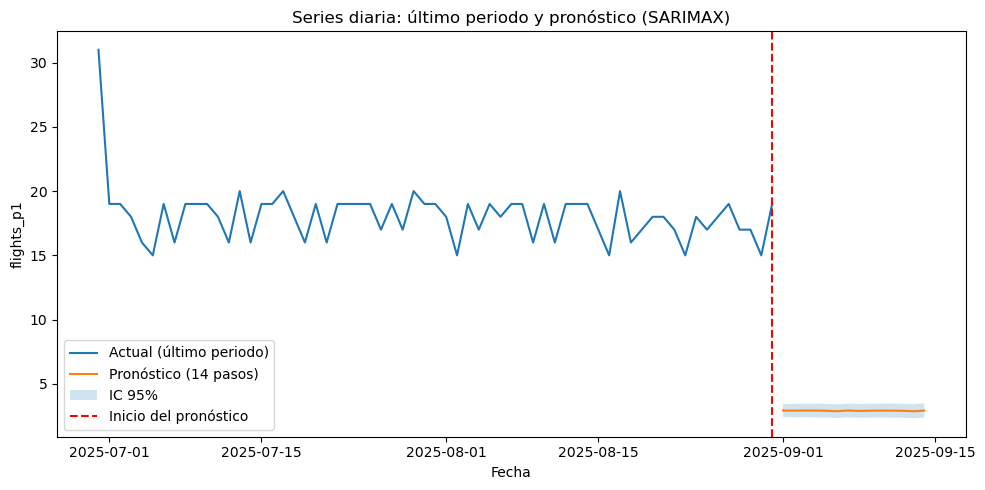

In [ ]:
# Prepare and auto-pick seasonality, then fit
y_prep = m._prepare_series(m.raw, m.date_col, m.value_col)
m.fit()

h = 14
fc_obj = m.res_.get_forecast(steps=h)
fc_df = pd.DataFrame({
    "mean": fc_obj.predicted_mean.astype(float),
    "lower": fc_obj.conf_int().iloc[:, 0].astype(float),
    "upper": fc_obj.conf_int().iloc[:, 1].astype(float),
})
fc_df.index.name = y_prep.index.name

# Actuals (daily, already prepared)
y_daily = y_prep

plot_last_period_with_forecast(
    actual=y_daily,
    forecast=fc_df,
    period=pd.DateOffset(months=2),
    title="Series diaria: último periodo y pronóstico (SARIMAX)",
    ylabel="flights_p1"
)
